In [6]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

CONFIG_RENAME_DICT = {
    'FolDE-random': 'random',
    # 'FolDE-Random-RandomForestCtrl': 'RandomForest',
    'OnlyNaturalness': 'zero-shot',
    'RandomToRandomForest-base': 'random forest',
    # 'FolDE-with-esmv1-nocl': 'FolDE',
    'FolDE-base': 'FolDE',
    'FolDE-no-constantliar': 'FolDE no constant-liar',
}

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '251003-test-benchmark',
    []
)
singles_mutant_df, singles_round_df = convert_compaign_result_collection_to_df(results)

singles_round_df['config_name'] = singles_round_df.config_name.apply(lambda x: CONFIG_RENAME_DICT.get(x, x))
singles_round_df['dms_shortname'] = singles_round_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])


# Load data for right panels (multimutant dataset)
multis_results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '251003-multimutant-benchmark',
    []
)
multis_mutant_df, multis_round_df = convert_compaign_result_collection_to_df(multis_results)
multis_round_df['config_name'] = multis_round_df.config_name.apply(lambda x: CONFIG_RENAME_DICT.get(x, x))
multis_round_df['dms_shortname'] = multis_round_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

round_metrics_df = pd.concat([singles_round_df, multis_round_df])


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading results for DMSs: {'LGK_LIPST_Klesmith_2015', 'MLAC_ECOLI_MacRae_2023', 'SC6A4_HUMAN_Young_2021', 'A4GRB6_PSEAI_Chen_2020', 'HMDH_HUMAN_Jiang_2019', 'CAS9_STRP1_Spencer_2017_positive', 'MSH2_HUMAN_Jia_2020', 'RNC_ECOLI_Weeks_2023', 'PPARG_HUMAN_Majithia_2016', 'AMIE_PSEAE_Wrenbeck_2017', 'MTHR_HUMAN_Weile_2021', 'PTEN_HUMAN_Mighell_2018', 'MET_HUMAN_Estevam_2023', 'PAI1_HUMAN_Huttinger_2021', 'S22A1_HUMAN_Yee_2023_activity', 'KCNJ2_MOUSE_Coyote-Maestas_2022_function', 'KKA2_KLEPN_Melnikov_2014'}
Loading results for DMSs: {'PABP_YEAST_Melamed_2013', 'GRB2_HUMAN_Faure_2021', 'SPG1_STRSG_Olson_2014'}


# Main Plotting Code

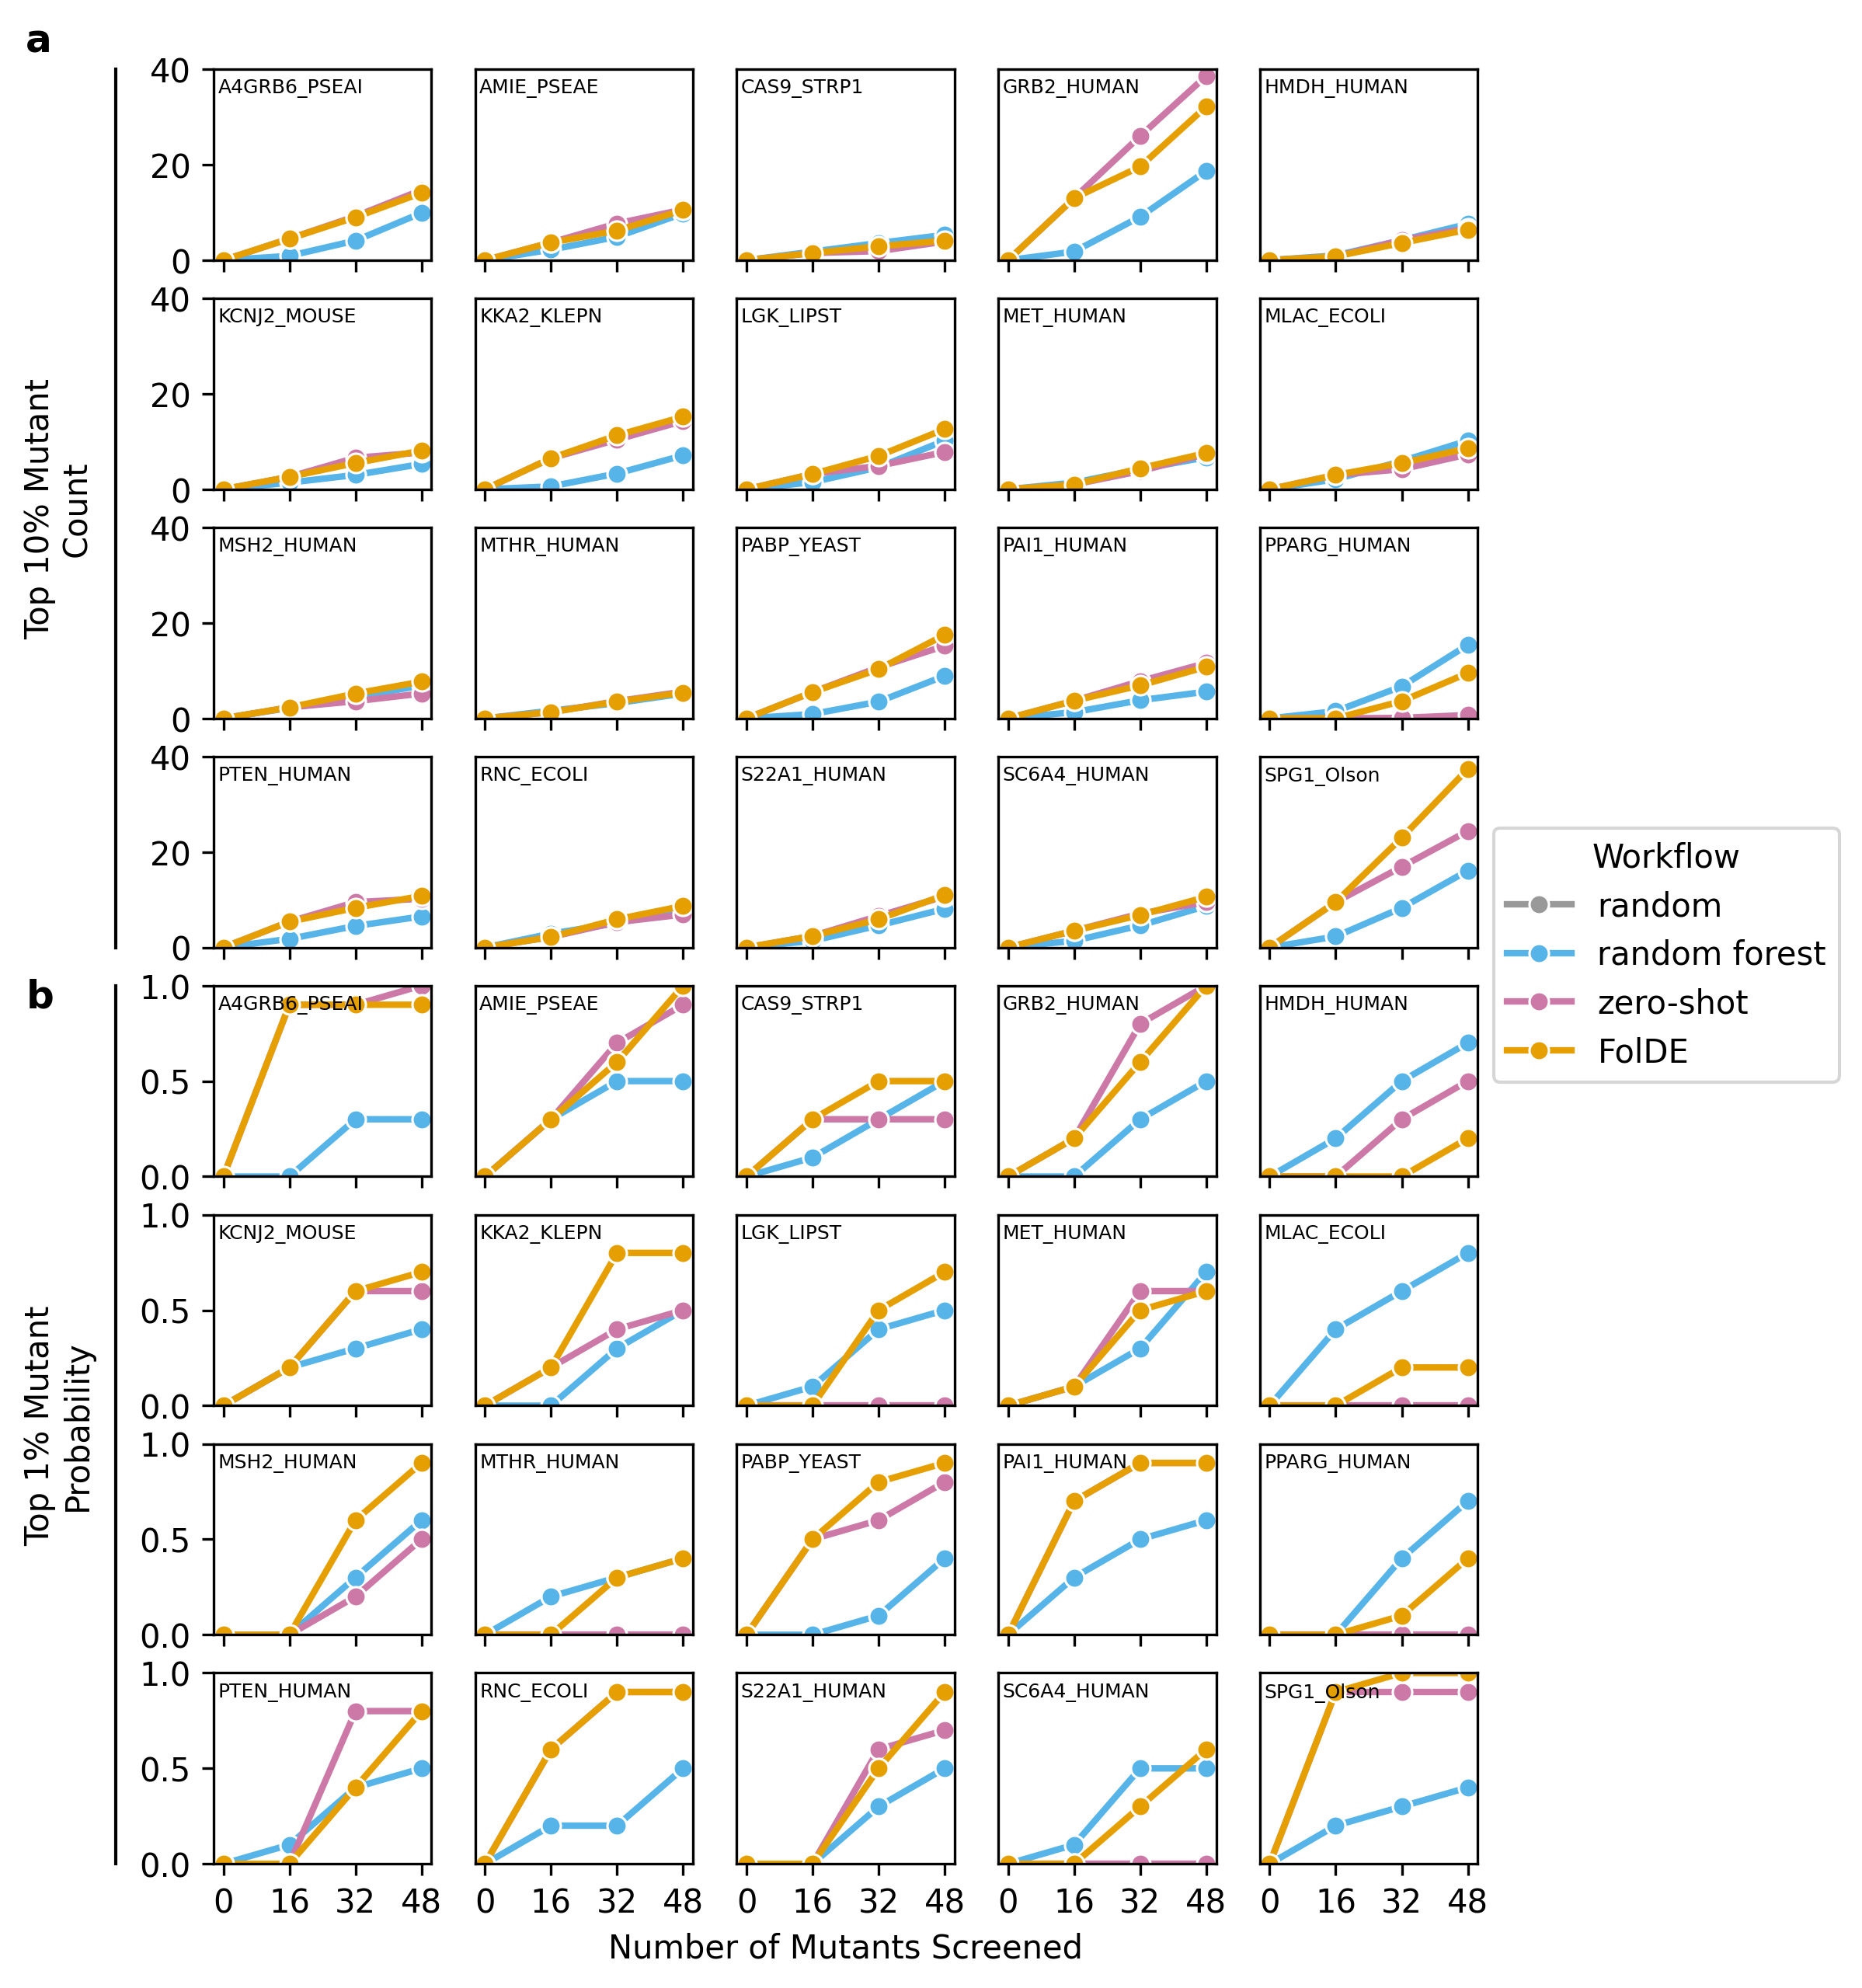

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

PLOT_SETUP = [
    # Okabe-Ito Colors:
	('random', '#999999'),
	('random forest', '#56B4E9'),
	('zero-shot', '#CC79A7'),
	('FolDE', '#E69F00'),

    # ('Random', 'lightgrey'),
    # ('RandomForest', '#bbcbdc'),
    # ('Zero-Shot', '#C0ACD7'),
    # ('FolDE', '#F1C233'),
    # ('FolDE no CL', 'blue')
]
WORKFLOWS = [v[0] for v in PLOT_SETUP]
palette = {v[0]: v[1] for v in PLOT_SETUP}

# List of proteins
DMS_ORDER = sorted(round_metrics_df['dms_shortname'].unique())

# Metrics to plot
METRICS = [
    ('cumulative_10pct_hits', "Top 10% Mutant\nCount"),
    ('has_found_top_1pct', "Top 1% Mutant\nProbability"),
]

fig, axes = plt.subplots(
    8, 5, figsize=(7, 10), dpi=300,
    sharex=True, sharey=False
)

axes = axes.flatten()

plot_df = pd.concat([round_metrics_df, pd.DataFrame([{
    'dms_shortname': dms_shortname,
    'config_name': config_name,
    'Screened mutants': 0,
    'round_num': 0,
    'cumulative_10pct_hits': 0,
    'has_found_top_1pct': 0,
} for config_name in WORKFLOWS for dms_shortname in DMS_ORDER])]).reset_index()

plot_df['Screened mutants'] = plot_df.round_num * 16


for idx, dms in enumerate(DMS_ORDER):
    # --- top half: metric 1 ---
    ax = axes[idx]
    subplot_df = plot_df.query("dms_shortname == @dms and config_name in @WORKFLOWS and round_num <= 3")

    sns.lineplot(
        ax=ax,
        data=subplot_df,
        x="Screened mutants",
        y=METRICS[0][0],
        hue="config_name",
        hue_order=WORKFLOWS,
        palette=palette,
        estimator="mean",
        errorbar=None,
        linewidth=2,
        marker='o',
    )

    ax.set_ylim(0, 40)
    ax.set_ylabel('')

# --- second half: metric 2 ---
for idx, dms in enumerate(DMS_ORDER, start=20):
    ax = axes[idx]
    subplot_df = plot_df.query("dms_shortname == @dms and config_name in @WORKFLOWS and round_num <= 3")

    sns.lineplot(
        ax=ax,
        data=subplot_df,
        x="Screened mutants",
        y=METRICS[1][0],
        hue="config_name",
        hue_order=WORKFLOWS,
        palette=palette,
        estimator="mean",
        errorbar=None,
        linewidth=2,
        marker='o',
    )
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('')

for idx, ax in enumerate(axes):
    dms = DMS_ORDER[idx % 20]
    ax.text(
        0.02, 0.95, f"{dms}", 
        transform=ax.transAxes, 
        ha="left", va="top",
        fontsize=6
    )
    if idx % 5 != 0:
        ax.set_yticks([])
    if idx < 35:
        ax.set_xticks([])
    else:
        ax.set_xticks([0, 16, 32, 48])
    if idx == 37:
        ax.set_xlabel("Number of Mutants Screened")
    else:
        ax.set_xlabel('')

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# Add y-axis labels with span bars for section a
X_POS_BARS = 0.065
X_POS_SUBFIGURE_LABELS = 0.010
X_POS_YLABELS = 0.03
middle_y_a = (axes[7].get_position().y0 + axes[12].get_position().y1) / 2
span_top_a = axes[2].get_position().y1
span_bottom_a = axes[17].get_position().y0

# Add label and bar for section a (no caps)
fig.text(X_POS_YLABELS, middle_y_a, METRICS[0][1], va='center', ha='center', fontsize=10, rotation=90)
fig.add_artist(plt.Line2D([X_POS_BARS, X_POS_BARS], [span_bottom_a, span_top_a], 
                          transform=fig.transFigure, color='black', linewidth=1))

# Add y-axis labels with span bars for section b
middle_y_b = (axes[27].get_position().y0 + axes[32].get_position().y1) / 2
span_top_b = axes[22].get_position().y1
span_bottom_b = axes[37].get_position().y0

# Add label and bar for section b (no caps)
fig.text(X_POS_YLABELS, middle_y_b, METRICS[1][1], va='center', ha='center', fontsize=10, rotation=90)
fig.add_artist(plt.Line2D([X_POS_BARS, X_POS_BARS], [span_bottom_b, span_top_b], 
                          transform=fig.transFigure, color='black', linewidth=1))

# Add panel labels a and b (smaller font, better positioned)
fig.text(X_POS_SUBFIGURE_LABELS, 0.90, 'a', fontsize=12, fontweight='bold', va='top', ha='left')
fig.text(X_POS_SUBFIGURE_LABELS, 0.490, 'b', fontsize=12, fontweight='bold', va='top', ha='left')

# Put one legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:len(WORKFLOWS)], labels[:len(WORKFLOWS)],
           title="Workflow", bbox_to_anchor=(0.90, 0.5), loc="center left")

# plt.tight_layout(rect=[0, 0, 0.95, 1])

plt.savefig('notebooks/jacob/paperplots/sup_pertarget_breakdown.png', dpi=300, bbox_inches='tight')

# Bar Graph Version

/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_54746/3367371003.py:99: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_54746/3367371003.py:99: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_54746/3367371003.py:99: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_54746/3367371003.py:99: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_54746/3367371003.py:99: F

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'A4GRB6_PSEAI'),
  Text(1, 0, 'AMIE_PSEAE'),
  Text(2, 0, 'CAS9_STRP1'),
  Text(3, 0, 'HMDH_HUMAN'),
  Text(4, 0, 'KCNJ2_MOUSE'),
  Text(5, 0, 'KKA2_KLEPN'),
  Text(6, 0, 'LGK_LIPST'),
  Text(7, 0, 'MET_HUMAN'),
  Text(8, 0, 'MLAC_ECOLI'),
  Text(9, 0, 'MSH2_HUMAN'),
  Text(10, 0, 'MTHR_HUMAN'),
  Text(11, 0, 'PAI1_HUMAN'),
  Text(12, 0, 'PPARG_HUMAN'),
  Text(13, 0, 'PTEN_HUMAN'),
  Text(14, 0, 'RNC_ECOLI'),
  Text(15, 0, 'S22A1_HUMAN'),
  Text(16, 0, 'SC6A4_HUMAN'),
  Text(17, 0, 'GRB2_HUMAN'),
  Text(18, 0, 'PABP_YEAST'),
  Text(19, 0, 'SPG1_Olson')])

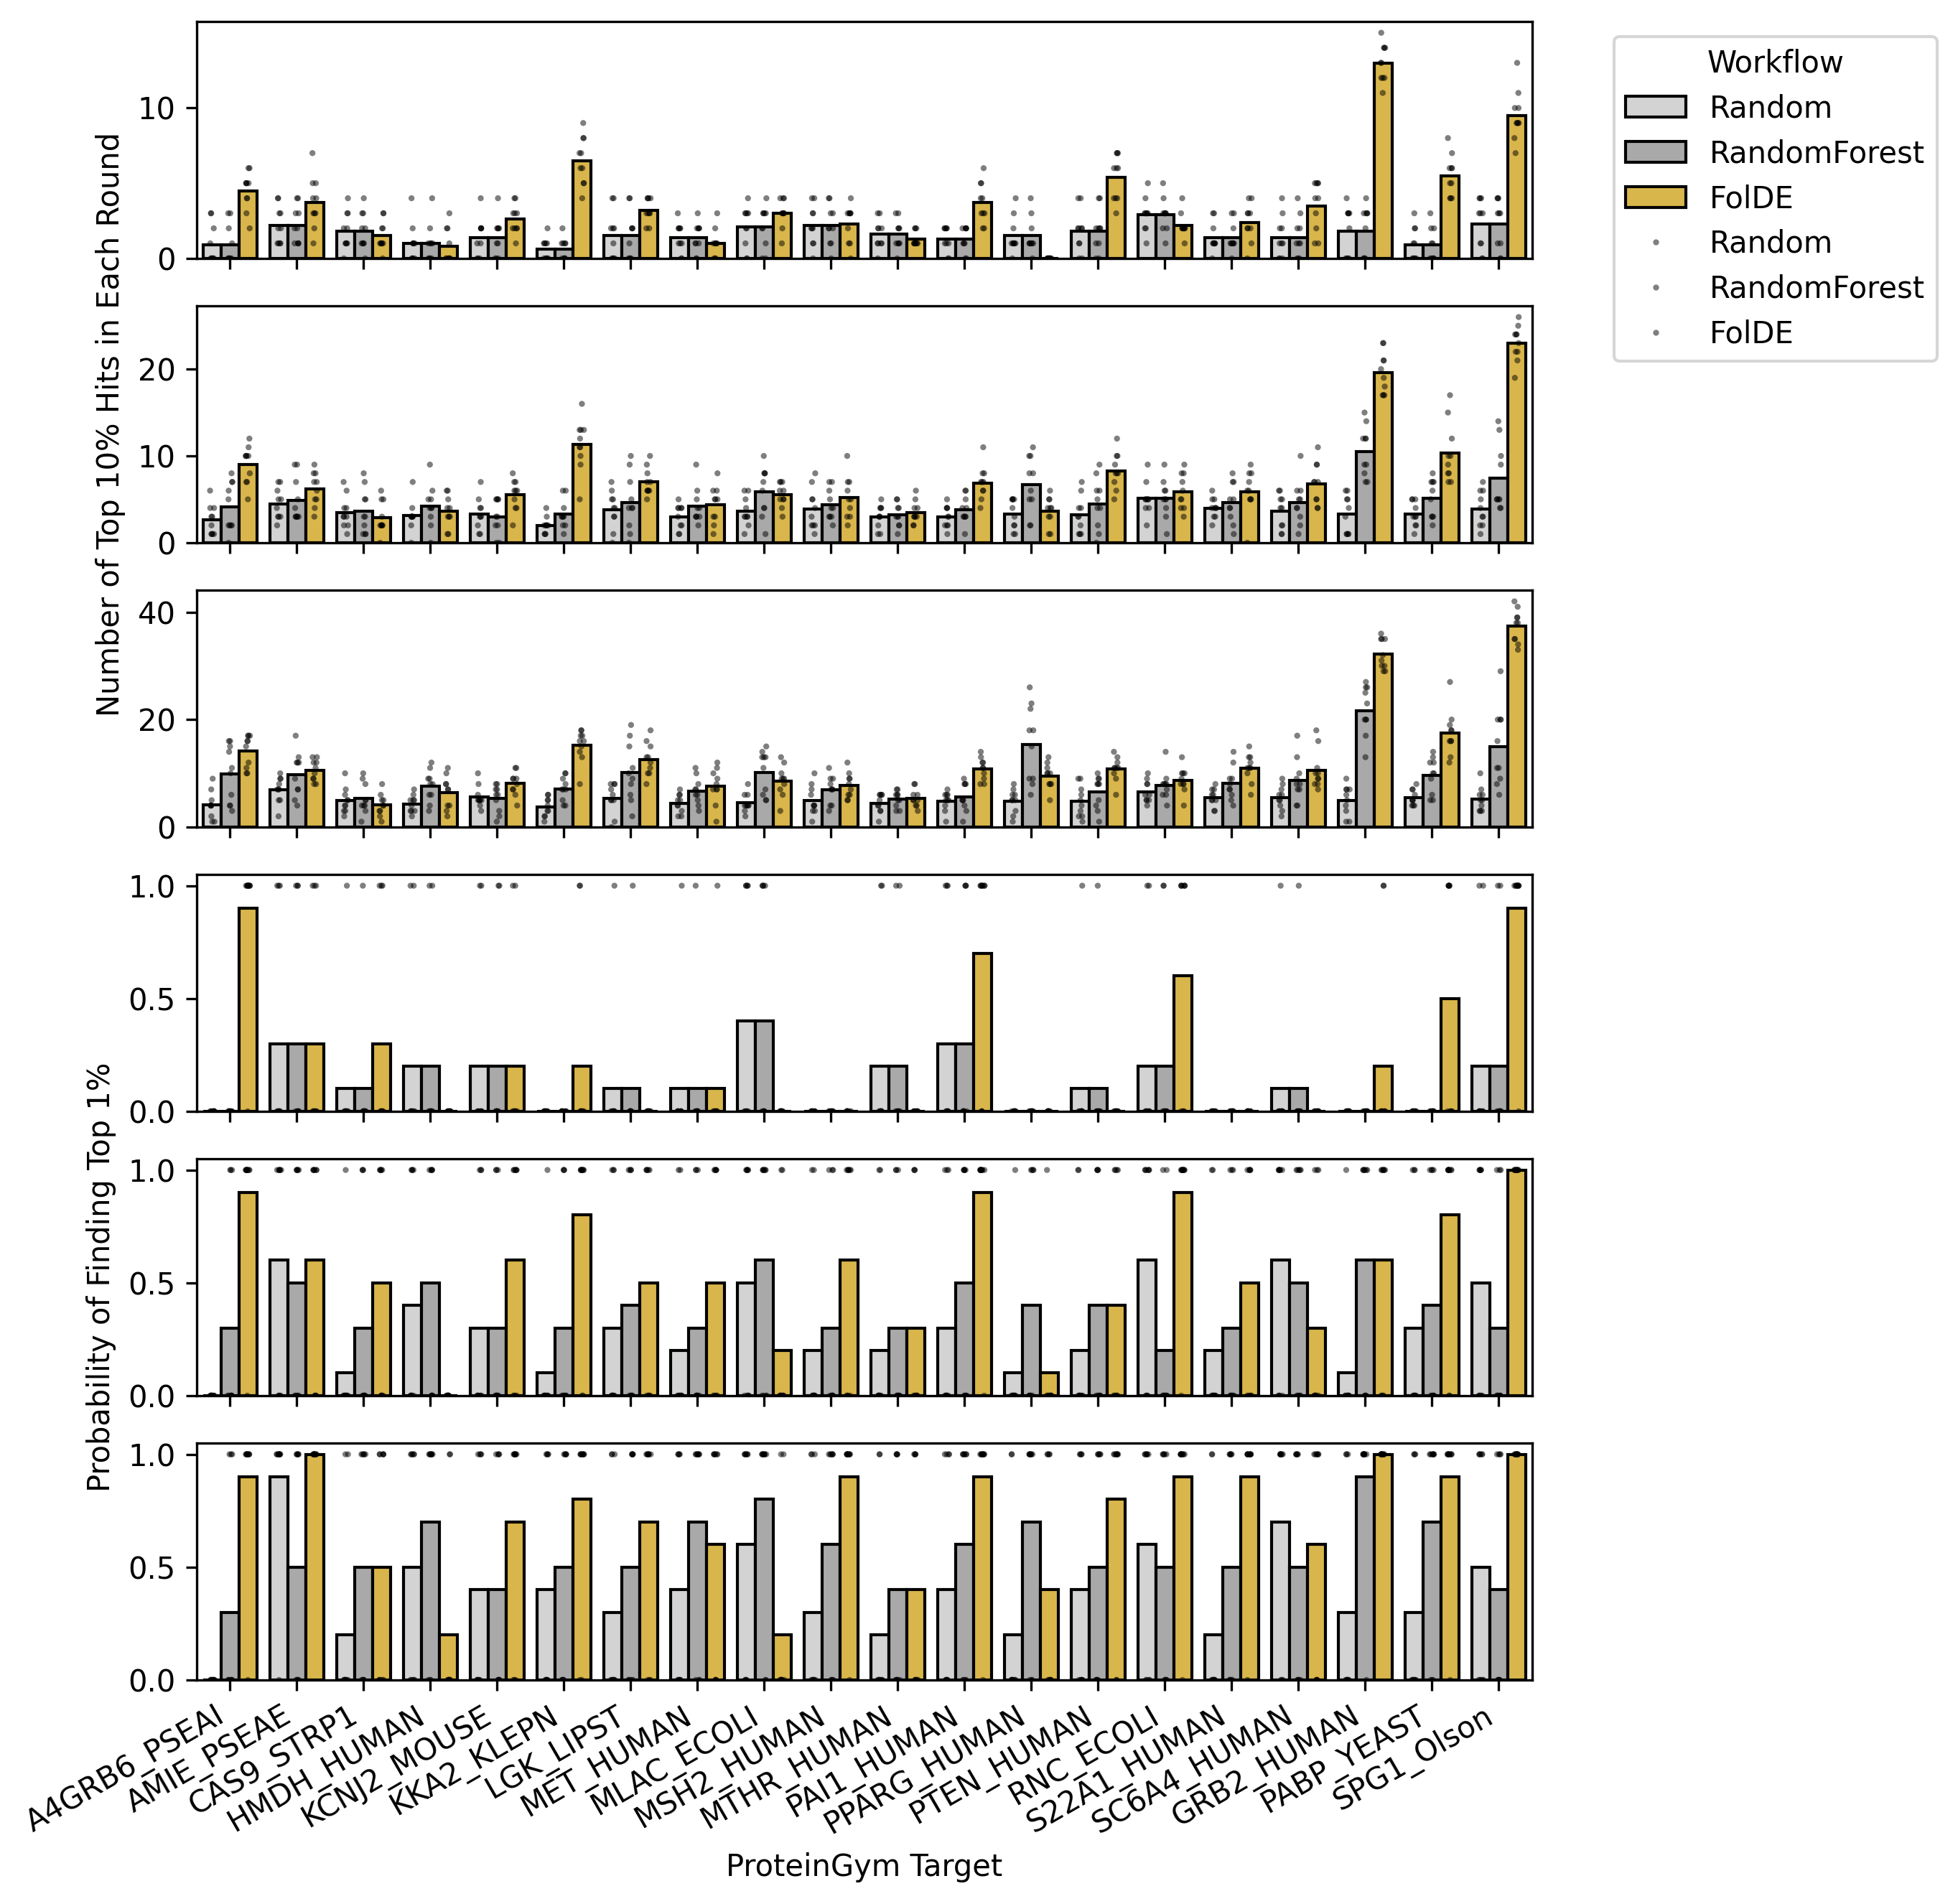

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
import scipy.stats as stats

# method1 = 'FolDE-Random-RandomForestCtrl'
PLOT_SETUP = [
    ('Random', 'lightgrey'),
    ('RandomForest', 'darkgrey'),
    ('FolDE', '#F1C233'),
    # ('FolDE-no-constantliar', 'grey'),
]
ANNOTATE_SIGNIFICANCE = False
WORKFLOWS = [v[0] for v in PLOT_SETUP]
palette = {v[0]: v[1] for v in PLOT_SETUP}

LINE_ALPHA = 0.1

BORDER_WIDTH = 1.0

DMS_ORDER = sorted(singles_round_df['dms_shortname'].unique()) + sorted(multis_round_df['dms_shortname'].unique())


def plot_aggregate_comparison(ax, data_df, metric, annotate_significance):
    sns.boxplot( # stripplot
        ax=ax,
        data=data_df,
        x="config_name",
        y=metric,
        hue="config_name",
        dodge=True,
        # jitter=True,
        # alpha=0.7,
        order=WORKFLOWS,
        hue_order=WORKFLOWS,
        palette=palette
    )

    for ii, (method1, method2) in enumerate(zip(WORKFLOWS[:-1], WORKFLOWS[1:])):
        for sim_id in data_df['sim_num'].unique():
            subset = data_df[
                (data_df['sim_num'] == sim_id)
            ].set_index('config_name')
            y1 = subset.loc[method1, metric]
            y2 = subset.loc[method2, metric]
            # Get the x position for this dms_shortname
            # Get the x positions for the two hues (dodge)
            ax.plot(
                [-0.3 + ii* 1.3, 1.0 + ii * 1.3],
                [y1, y2],
                color='gray',
                alpha=LINE_ALPHA,
                zorder=1
            )

    if annotate_significance:
        ax1_pairs = [
            ((mleft,), (mright,)) for mleft, mright in zip(WORKFLOWS[:-1], WORKFLOWS[1:])
        ]

        # ax1_pairs = [
        #     ((WORKFLOWS[0], ), (WORKFLOWS[1], )),
        #     ((WORKFLOWS[1], ), (WORKFLOWS[2], )),
        # ]
        annot1 = Annotator(
            ax,
            ax1_pairs,
            data=data_df,
            x='config_name',
            y=metric,
            hue="config_name",
            order=WORKFLOWS,
            hue_order=WORKFLOWS,
        )
        annot1.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
        annot1.apply_test()
        annot1.annotate()

    ax.set_ylabel('')
    ax.set_xlabel('')


def plot_breakdown_comparison(ax, data_df, metric, annotate_significance):
    # sns.boxplot(
    #     ax=ax,
    #     data=data_df,
    #     x="dms_shortname",
    #     y=metric,
    #     hue="config_name",
    #     dodge=True,
    #     # jitter=True,
    #     # alpha=0.7,
    #     order=DMS_ORDER,
    #     hue_order=WORKFLOWS,
    #     palette=palette,
    #     # edgecolor='black',
    #     linewidth=BORDER_WIDTH,
    # )
    sns.barplot(
        ax=ax,
        data=data_df,
        x="dms_shortname",
        y=metric,
        hue="config_name",
        # dodge=True,
        # jitter=True,
        # alpha=0.7,
        order=DMS_ORDER,
        hue_order=WORKFLOWS,
        palette=palette,
        edgecolor='black',
        linewidth=BORDER_WIDTH,
        errwidth=0,
    )

    sns.stripplot(
        ax=ax,
        data=data_df,
        x="dms_shortname",
        y=metric,
        hue="config_name",
        dodge=True,
        alpha=0.5,
        order=DMS_ORDER,
        hue_order=WORKFLOWS,
        palette={v: 'black' for v in palette.keys()},
        size=2,
    )

    pairs = []

    # # Connect the two config points for each dms_shortname
    # for dms in DMS_ORDER:
    #     for ii, (method1, method2) in enumerate(zip(WORKFLOWS[:-1], WORKFLOWS[1:])):
    #         pairs.append(
    #             ((dms, method1), (dms, method2))
    #         )

    #         for sim_id in data_df['sim_num'].unique():
    #             subset = data_df[
    #                 (data_df['dms_shortname'] == dms) &
    #                 (data_df['sim_num'] == sim_id)
    #             ].set_index('config_name')
    #             y1 = subset.loc[method1, metric]
    #             y2 = subset.loc[method2, metric]
    #             # Get the x position for this dms_shortname
    #             x_pos = DMS_ORDER.index(dms)
    #             # Get the x positions for the two hues (dodge)
    #             offsets = [-0.2 + ii * 0.2, 0.0 + ii * 0.2]  # adjust if your dodge is different
    #             ax.plot(
    #                 [x_pos + offsets[0], x_pos + offsets[1]],
    #                 [y1, y2],
    #                 color='gray',
    #                 alpha=LINE_ALPHA,
    #                 zorder=1
    #             )


    if annotate_significance:
        annot = Annotator(
            ax,
            pairs,
            data=data_df,
            x="dms_shortname",
            y=metric,
            hue="config_name",
            comparisons_correction='bonferroni',
            order=DMS_ORDER,
            hue_order=WORKFLOWS
        )
        annot.configure(test='t-test_paired', verbose=2)  #'t-test_ind'  Mann-Whitney
        annot.apply_test()
        annot.annotate()

    ax.set_ylabel('')
    ax.set_xlabel('')


fig, axes = plt.subplots(6, 1, figsize=(8, 10), dpi=300, sharex=True)#, height_ratios=[2, 1, 1, 1, 1, 1, 1])

for ax, (metric, round) in zip(axes, [
    # ('enrichment', None),
    ('cumulative_10pct_hits', 1),
    ('cumulative_10pct_hits', 2),
    ('cumulative_10pct_hits', 3),
    ('has_found_top_1pct', 1),
    ('has_found_top_1pct', 2),
    ('has_found_top_1pct', 3),
    # ('enrichment_1pct', 1),
    # ('enrichment_1pct', 2),
    # ('enrichment_1pct', 3),
    # ('enrichment_10pct', 1),
    # ('enrichment_10pct', 2),
    # ('enrichment_10pct', 3),
    # ('held_out_1pct_recall', 1),
    # ('held_out_1pct_recall', 2),
    # ('held_out_1pct_recall', 3),
    # ('held_out_10pct_recall', 1),
    # ('held_out_10pct_recall', 2),
    # ('held_out_10pct_recall', 3),
]):
    if metric == 'enrichment': 
        plot_df = full_stats[-2].copy().reset_index()
        plot_df['dms_shortname'] = plot_df['dms_id'].apply(lambda x: DMS_SHORTNAMES[x])
        sns.barplot(
            ax=ax,
            data=plot_df,
            x="dms_shortname",
            y=metric,
            hue="config_name",
            # dodge=True,
            # jitter=True,
            # alpha=0.7,
            order=DMS_ORDER,
            hue_order=WORKFLOWS,
            palette=palette,
            edgecolor='black',
            linewidth=BORDER_WIDTH,
        )
        ax.axhline(y=1.0, color='lightgrey', linestyle='--')
    else:

        comparison_df = round_metrics_df.copy()
        comparison_df = comparison_df[
            comparison_df.config_name.isin(WORKFLOWS) & (round_metrics_df.round_num == round)
        ].sort_values(['dms_id', 'config_name', 'sim_num']).copy()

        # plot_aggregate_comparison(leftax, comparison_df, metric, ANNOTATE_SIGNIFICANCE)
        plot_breakdown_comparison(ax, comparison_df, metric, ANNOTATE_SIGNIFICANCE)


# for ax in [ax2, ax4, ax6]:
#     ax.set_yticks([])
# for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
#     ax.set_ylim(YRANGE[0], YRANGE[1])
# for ax in [ax4, ax6]:
#     ax.set_legend(False)

# enrichment_1pct_max = round_metrics_df[round_metrics_df.config_name.isin(WORKFLOWS) & (round_metrics_df.round_num <= 3) & round_metrics_df.dms_shortname.isin(DMS_ORDER)].enrichment_1pct.max()
# enrichment_10pct_max = round_metrics_df[round_metrics_df.config_name.isin(WORKFLOWS) & (round_metrics_df.round_num <= 3) & round_metrics_df.dms_shortname.isin(DMS_ORDER)].enrichment_10pct.max()
# # enrichment_1pct_max = min(30, enrichment_1pct_max)
# for ax in axes[0:3]:
#     ax.set_ylim(0, enrichment_1pct_max)
# for ax in axes[3:6]:
#     ax.set_ylim(0, enrichment_10pct_max)
# axes[0].set_ylim(0, 10.0)
# axes[0].set_yscale('log')
# ax.set_ylim(0, ax.get_ylim()[1])

# axes[0].set_ylabel('Enrichment')
axes[1].set_ylabel('Number of Top 10% Hits in Each Round')
axes[4].set_ylabel('Probability of Finding Top 1%')
    
# Put legend on ax0 only, to the right of the plot
for ax in axes[1:]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()
axes[0].legend(title='Workflow', bbox_to_anchor=(1.05, 1), loc='upper left')

axes[-1].set_xlabel('ProteinGym Target')

# plt.title(f'Performance Difference At Round {ROUND}')
# for ax in axes[:-1]:
#     ax.set_xticks([])
plt.sca(axes[-1])  # Set current axis
plt.xticks(rotation=30, ha="right")
# plt.tight_layout()
# plt.show()


## The old plotting code

In [ ]:


for metric in ['held_out_1pct_recall', 'held_out_10pct_recall']:
    fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(FIG_WIDTH, 7), dpi=300, width_ratios=(1,5), sharey='row')

    for ROUND, (leftax, rightax) in [(1, (ax1, ax2)), (2, (ax3, ax4)), (3, (ax5, ax6))]:
        comparison_df = round_metrics_df.copy()
        comparison_df = comparison_df[
            comparison_df.config_name.isin(methods) & (round_metrics_df.round_num == ROUND)
        ].sort_values(['dms_id', 'config_name', 'sim_num']).copy()

        # Sort dms_shortname for consistent x-axis order
        ordered_dms = sorted(comparison_df['dms_shortname'].unique())

        plot_aggregate_comparison(leftax, comparison_df, metric, ANNOTATE_SIGNIFICANCE)
        plot_breakdown_comparison(rightax, comparison_df, metric, ANNOTATE_SIGNIFICANCE)

    for ax in [ax1, ax2, ax3, ax4]:
        ax.set_xticks([])

    plt.sca(ax5)  # Set current axis
    plt.xticks(rotation=15, ha='right')
    plt.sca(ax6)
    plt.xticks(rotation=15, ha='right')
    # for ax in [ax2, ax4, ax6]:
    #     ax.set_yticks([])
    # for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    #     ax.set_ylim(YRANGE[0], YRANGE[1])
    # for ax in [ax4, ax6]:
    #     ax.set_legend(False)

    for ax in [ax1, ax3, ax5]:
        if metric == 'held_out_1pct_recall':
            ax.set_ylabel('Held Out 1% Recall')
        elif metric == 'held_out_10pct_recall':
            ax.set_ylabel('Held Out 10% Recall')
        else:
            ax.set_ylabel(metric)
        
    # Put legend on ax3 only, to the right of the plot
    for ax in [ax1, ax2, ax3, ax5, ax6]:
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    ax4.legend(title='Workflow', bbox_to_anchor=(1.05, 1), loc='upper left')

    ax5.set_xlabel('Workflow')
    ax6.set_xlabel('ProteinGym Target')

    # plt.title(f'Performance Difference At Round {ROUND}')
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

In [ ]:
# 1. Pivot the DataFrame to get paired values side by side
for metric in ['held_out_1pct_recall', 'held_out_10pct_recall']:
    for round_num in [1, 2, 3, 'allrounds']:
        method1 = 'RandomForest'
        method2 = 'FolDE'
        if round_num == 'allrounds':
            subset_df = round_metrics_df.copy()
        else:
            subset_df = round_metrics_df[round_metrics_df.round_num == round_num]
        paired = subset_df.pivot_table(
            index=['dms_id', 'sim_num'],  # or add more columns if needed for unique pairing
            columns='config_name',
            values=metric
        )

        t_stat, p_value = stats.ttest_rel(paired[method1], paired[method2])
        means = paired.mean(axis=0)

        print(f"{metric} R{round_num} {method1}: {means[method1]:.3f}, {method2}: {means[method2]:.3f}: up = {100.0*(means[method2] - means[method1])/means[method1]:.3f}% (Paired t-test: t = {t_stat:.3f}, p = {p_value:.3g})")


# # 2. Drop any rows with missing values (i.e., where a pair is incomplete)
# paired = paired.dropna(subset=[method1, method2])

held_out_1pct_recall R1 RandomForest: 0.011, FolDE: 0.031: up = 191.395% (Paired t-test: t = -7.215, p = 1.73e-11)
held_out_1pct_recall R2 RandomForest: 0.015, FolDE: 0.024: up = 58.704% (Paired t-test: t = -3.024, p = 0.00289)
held_out_1pct_recall R3 RandomForest: 0.019, FolDE: 0.029: up = 52.218% (Paired t-test: t = -2.897, p = 0.00427)
held_out_1pct_recall Rallrounds RandomForest: 0.022, FolDE: 0.034: up = 51.188% (Paired t-test: t = -4.072, p = 7.14e-05)
held_out_10pct_recall R1 RandomForest: 0.101, FolDE: 0.175: up = 73.997% (Paired t-test: t = -22.420, p = 1.62e-52)
held_out_10pct_recall R2 RandomForest: 0.139, FolDE: 0.173: up = 24.282% (Paired t-test: t = -10.173, p = 2.91e-19)
held_out_10pct_recall R3 RandomForest: 0.155, FolDE: 0.180: up = 15.974% (Paired t-test: t = -7.352, p = 7.99e-12)
held_out_10pct_recall Rallrounds RandomForest: 0.146, FolDE: 0.184: up = 25.944% (Paired t-test: t = -15.176, p = 2.24e-33)


In [ ]:
method1 = 'RandomForest'
method2 = 'FolDE'
if round_num == 'allrounds':
    subset_df = round_metrics_df.copy()
else:
    subset_df = round_metrics_df[round_metrics_df.round_num == round_num]
melted_subset_df = subset_df[['config_name', 'dms_id', 'sim_num', 'round_num', 'held_out_1pct_recall', 'held_out_10pct_recall']].melt(id_vars=['config_name', 'dms_id', 'sim_num', 'round_num'], var_name='metric_name', value_name='metric_value')
paired = melted_subset_df.pivot_table(
    index=['dms_id', 'metric_name', 'round_num', 'sim_num'],  # or add more columns if needed for unique pairing
    columns='config_name',
    values='metric_value'
)
paired

config_name                                                        FolDE  \
dms_id                 metric_name           round_num sim_num             
A4GRB6_PSEAI_Chen_2020 held_out_10pct_recall 1         0        0.247012   
                                                       1        0.219124   
                                                       2        0.286853   
                                                       3        0.239044   
                                                       4        0.235060   
...                                                                  ...   
SC6A4_HUMAN_Young_2021 held_out_1pct_recall  6         5        0.017241   
                                                       6        0.051724   
                                                       7        0.051724   
                                                       8        0.017241   
                                                       9        0.051724   

config_name                                                     FolDE-no-constantliar  \
dms_id                 metric_name           round_num sim_num                          
A4GRB6_PSEAI_Chen_2020 held_out_10pct_recall 1         0                     0.247012   
                                                       1                     0.219124   
                                                       2                     0.286853   
                                                       3                     0.239044   
                                                       4                     0.235060   
...                                                                               ...   
SC6A4_HUMAN_Young_2021 held_out_1pct_recall  6         5                     0.000000   
                                                       6                     0.000000   
                                                       7                     0.051724   
                                                       8                     0.034483   
                                                       9                     0.034483   

config_name                                                       Random  \
dms_id                 metric_name           round_num sim_num             
A4GRB6_PSEAI_Chen_2020 held_out_10pct_recall 1         0        0.147410   
                                                       1        0.115538   
                                                       2        0.087649   
                                                       3        0.115538   
                                                       4        0.099602   
...                                                                  ...   
SC6A4_HUMAN_Young_2021 held_out_1pct_recall  6         5        0.000000   
                                                       6        0.017241   
                                                       7        0.000000   
                                                       8        0.000000   
                                                       9        0.017241   

config_name                                                     RandomForest  \
dms_id                 metric_name           round_num sim_num                 
A4GRB6_PSEAI_Chen_2020 held_out_10pct_recall 1         0            0.147410   
                                                       1            0.115538   
                                                       2            0.087649   
                                                       3            0.115538   
                                                       4            0.099602   
...                                                                      ...   
SC6A4_HUMAN_Young_2021 held_out_1pct_recall  6         5            0.000000   
                                                       6            0.000000   
                                                       7        

In [ ]:
t_stat, p_value = stats.ttest_rel(paired[method1], paired[method2])
means = paired.mean(axis=0)

print(f"All metrics all rounds {method1}: {means[method1]:.3f}, {method2}: {means[method2]:.3f}: up = {100.0*(means[method2] - means[method1])/means[method1]:.3f}% (Paired t-test: t = {t_stat:.3f}, p = {p_value:.3g})")


All metrics all rounds RandomForest: 0.084, FolDE: 0.109: up = 29.286% (Paired t-test: t = -22.820, p = 7.65e-103)


round_number
1    0.13
2    0.27
3    0.33
Name: prob_found_top_1pct, dtype: float64

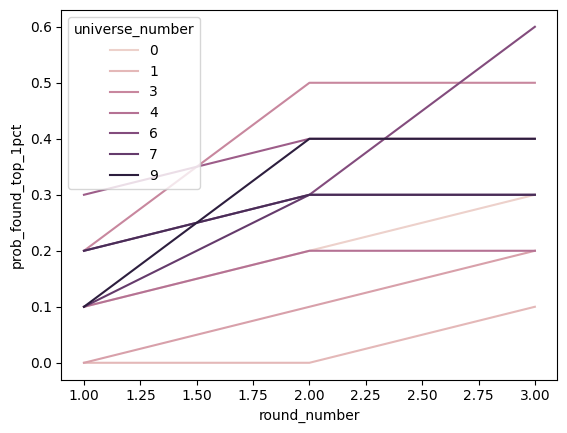

In [ ]:
import random

sim_data_list = []

for universe in range(10):
    sims_that_found_top_1pct = [0, 0, 0]
    for sim in range(10):
        found_top_1pct = False
        for round in range(3):
            for mutant in range(16):
                found_top_1pct = found_top_1pct or random.random() <= 0.01
            if found_top_1pct:
                sims_that_found_top_1pct[round] += 1
    for round in range(3):
        sim_data_list.append({
            'universe_number': universe,
            'round_number': round + 1,
            'prob_found_top_1pct': sims_that_found_top_1pct[round] / 10.0
        })
sim_data_df = pd.DataFrame(sim_data_list)
sns.lineplot(sim_data_df, x='round_number', y='prob_found_top_1pct', hue='universe_number')
sim_data_df.groupby('round_number').prob_found_top_1pct.mean()

round_num
1    0.125
2    0.290
3    0.390
Name: has_found_top_1pct, dtype: float64

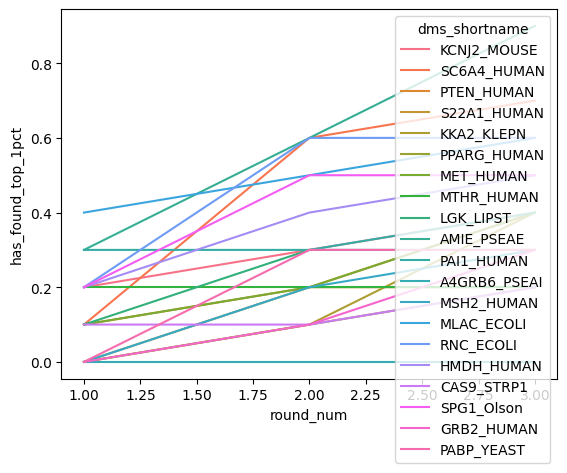

In [ ]:
real_plot_df = round_metrics_df.query("config_name == 'Random' and round_num <= 3")
sns.lineplot(real_plot_df, x='round_num', y='has_found_top_1pct', hue='dms_shortname', errorbar=None)
real_plot_df.groupby('round_num').has_found_top_1pct.mean()

Running simulation...


100%|██████████| 1000000/1000000 [00:05<00:00, 171031.65it/s]


Simulation Results:
Mean number of 1s: 0.7484 (theoretical: 0.7500)
Standard deviation: 0.8434 (theoretical: 0.8441)


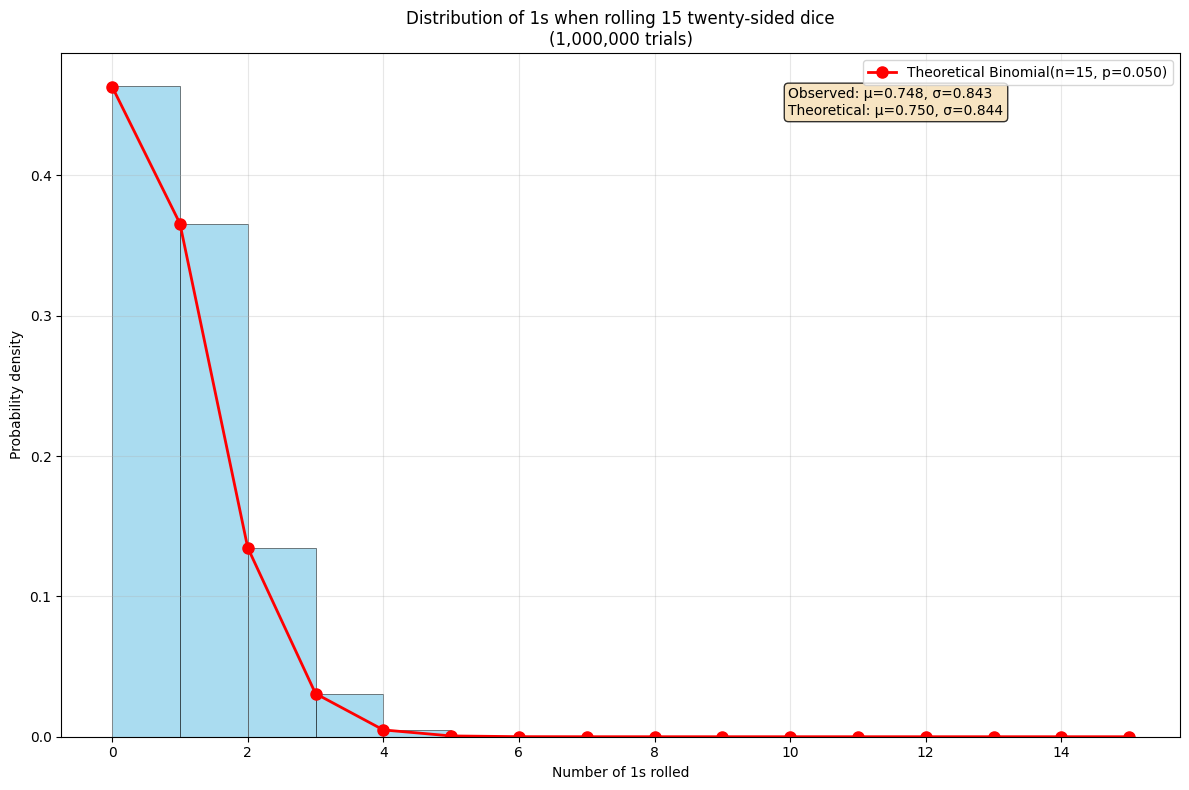


Frequency Distribution:
Number of 1s | Count | Probability | Theoretical Prob
-------------------------------------------------------
          0 | 464005 | 0.464005 | 0.463291
          1 | 365771 | 0.365771 | 0.365756
          2 | 134201 | 0.134201 | 0.134752
          3 | 30511 | 0.030511 | 0.030733
          4 |  4889 | 0.004889 | 0.004853
          5 |   573 | 0.000573 | 0.000562
          6 |    48 | 0.000048 | 0.000049
          7 |     2 | 0.000002 | 0.000003


In [ ]:
# Simulate rolling a 20 sided die 1,000,000 times and measuring the number of universes in which we get 1 1, 2 1s, 3 1s, etc.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm

# Set random seed for reproducibility
np.random.seed(42)

# Simulation parameters
n_dice = 15  # Number of dice per roll
n_trials = 1_000_000  # Number of experiments
sides = 20  # Number of sides on each die
prob_one = 1/20  # Probability of rolling a 1 on any die

# Simulate rolling 15 dice, 1,000,000 times
# For each trial, count how many 1s we get
ones_count = []

print("Running simulation...")
for trial in tqdm(range(n_trials)):
    # Roll 15 dice
    dice_rolls = np.random.randint(1, sides + 1, n_dice)
    # Count the number of 1s
    num_ones = np.sum(dice_rolls == 1)
    ones_count.append(num_ones)

ones_count = np.array(ones_count)

# Calculate statistics
mean_ones = np.mean(ones_count)
std_ones = np.std(ones_count)

# Theoretical values (binomial distribution)
theoretical_mean = n_dice * prob_one
theoretical_std = np.sqrt(n_dice * prob_one * (1 - prob_one))

print(f"Simulation Results:")
print(f"Mean number of 1s: {mean_ones:.4f} (theoretical: {theoretical_mean:.4f})")
print(f"Standard deviation: {std_ones:.4f} (theoretical: {theoretical_std:.4f})")

# Create histogram of results
plt.figure(figsize=(12, 8))

# Plot histogram
counts, bins, patches = plt.hist(ones_count, bins=range(0, max(ones_count) + 2), 
                                alpha=0.7, density=True, color='skyblue', 
                                edgecolor='black', linewidth=0.5)

# Overlay theoretical binomial distribution
x_theoretical = np.arange(0, n_dice + 1)
y_theoretical = stats.binom.pmf(x_theoretical, n_dice, prob_one)
plt.plot(x_theoretical, y_theoretical, 'ro-', markersize=8, linewidth=2, 
         label=f'Theoretical Binomial(n={n_dice}, p={prob_one:.3f})')

plt.xlabel('Number of 1s rolled')
plt.ylabel('Probability density')
plt.title(f'Distribution of 1s when rolling {n_dice} twenty-sided dice\n({n_trials:,} trials)')
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics text box
textstr = f'Observed: μ={mean_ones:.3f}, σ={std_ones:.3f}\nTheoretical: μ={theoretical_mean:.3f}, σ={theoretical_std:.3f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.65, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Print frequency table
print("\nFrequency Distribution:")
print("Number of 1s | Count | Probability | Theoretical Prob")
print("-" * 55)
for i in range(max(ones_count) + 1):
    observed_count = np.sum(ones_count == i)
    observed_prob = observed_count / n_trials
    theoretical_prob = stats.binom.pmf(i, n_dice, prob_one)
    if observed_count > 0:
        print(f"{i:11d} | {observed_count:5d} | {observed_prob:.6f} | {theoretical_prob:.6f}")